# Lab 10

Description of lab:

What are the advantages and disadvantages of a linear probability model? What is logistic regression, and how is it different from standard linear regression? Interpretting the results of a logistic regression. How to visualize the results of a logistic regression.

In [3]:
# Importing packages and preferences:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

pd.set_option('display.max_columns', None)

### Voting

In [4]:
politics = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/nes.csv")
politics.head()

,Unnamed: 0,year,resid,weight1,weight2,weight3,age,gender,race,educ1,urban,region,income,occup1,union,religion,educ2,educ3,martial_status,occup2,icpsr_cty,fips_cty,partyid7,partyid3,partyid3_b,str_partyid,father_party,mother_party,dlikes,rlikes,dem_therm,rep_therm,regis,vote,regisvote,presvote,presvote_2party,presvote_intent,ideo_feel,ideo7,ideo,cd,state,inter_pre,inter_post,black,female,age_sq,rep_presvote,rep_pres_intent,south,real_ideo,presapprov,perfin1,perfin2,perfin,presadm,age_10,age_sq_10,newfathe,newmoth,parent_party,white,year_new,income_new,age_new,vote.1,age_discrete,race_adj,dvote,rvote
0,536,1952,1,1.0,1.0,1.0,25,2,1,2,2.0,1,4,2.0,1.0,1.0,3,3,1.0,2.0,NaN,NaN,6.0,3.0,3.0,3.0,3.0,3.0,0.0,1.0,NaN,NaN,2.0,2.0,3.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,13,50.0,NaN,0,1,625,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN,-1,2.5,6.250000,1.0,1.0,2.0,1,1,1,-2.052455,1.0,1,1.0,0.0,1.0
1,537,1952,2,1.0,1.0,1.0,33,2,1,1,2.0,1,4,6.0,1.0,1.0,1,1,1.0,6.0,NaN,NaN,5.0,3.0,3.0,2.0,2.0,2.0,-1.0,3.0,NaN,NaN,2.0,2.0,3.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,13,50.0,NaN,0,1,1089,0.0,1.0,0,NaN,NaN,NaN,NaN,NaN,-1,3.3,10.889999,0.0,0.0,0.0,1,1,1,-1.252455,1.0,2,1.0,1.0,0.0
2,538,1952,3,1.0,1.0,1.0,26,2,1,2,2.0,1,3,6.0,2.0,2.0,3,3,1.0,6.0,NaN,NaN,4.0,2.0,2.0,1.0,1.0,1.0,0.0,5.0,NaN,NaN,2.0,2.0,3.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,13,50.0,NaN,0,1,676,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN,-1,2.6,6.759999,-1.0,-1.0,-2.0,1,1,0,-1.952455,1.0,1,1.0,0.0,1.0
3,539,1952,4,1.0,1.0,1.0,63,1,1,2,2.0,1,3,3.0,1.0,1.0,2,2,1.0,3.0,NaN,NaN,7.0,3.0,3.0,4.0,1.0,NaN,-1.0,3.0,NaN,NaN,1.0,2.0,3.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,13,50.0,NaN,0,0,3969,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN,-1,6.3,39.690002,-1.0,NaN,NaN,1,1,0,1.747545,1.0,3,1.0,0.0,1.0
4,540,1952,5,1.0,1.0,1.0,66,2,1,2,2.0,2,1,6.0,2.0,1.0,4,4,1.0,6.0,NaN,NaN,7.0,3.0,3.0,4.0,1.0,1.0,-2.0,0.0,NaN,NaN,2.0,2.0,3.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,24,49.0,NaN,0,1,4356,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN,-1,6.6,43.559998,-1.0,-1.0,-2.0,1,1,-2,2.047545,1.0,4,1.0,0.0,1.0


In [5]:
politics.shape

(34908, 71)

In [6]:
# Limit the data to only 1992:
politics92 = politics.loc[politics['year'] == 1992].copy()

# Subtract income by one so the intercept corresponds to the lowest income category:
politics92['income_m1'] = politics92['income'] - 1

Use a linear probability model to interpret the coefficients as probabilities, just use ols with the normal 0/1 data on the left side. 

In [7]:
mod1 = smf.ols('rvote ~ income_m1', data = politics92).fit()
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  rvote   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     24.23
Date:                Tue, 05 Dec 2023   Prob (F-statistic):           9.60e-07
Time:                        17:35:39   Log-Likelihood:                -909.78
No. Observations:                1356   AIC:                             1824.
Df Residuals:                    1354   BIC:                             1834.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2278      0.028      8.054      0.000       0.172       0.283
income_m1      0.0589      0.012      4.922      0.000       0.035       0.082
==============================================================================
Omnibus:                     7972.680   Durbin-Watson:                   2.073
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              219.817
Skew:                           0.602   Prob(JB):                     1.85e-48
Kurtosis:                       1.438   Cond. No.                         5.96
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
# Generate income data from a normal distribution, I assume de-meaned data, so it is centered around 0:
income = pd.Series(spt.norm.rvs(1, 100, size = 10000))
income

0        -8.138408
1        41.496171
2        33.892765
3      -123.385091
4        -7.373921
           ...    
9995    -66.003390
9996   -110.264491
9997    -37.080501
9998    -62.140800
9999    -30.405237
Length: 10000, dtype: float64

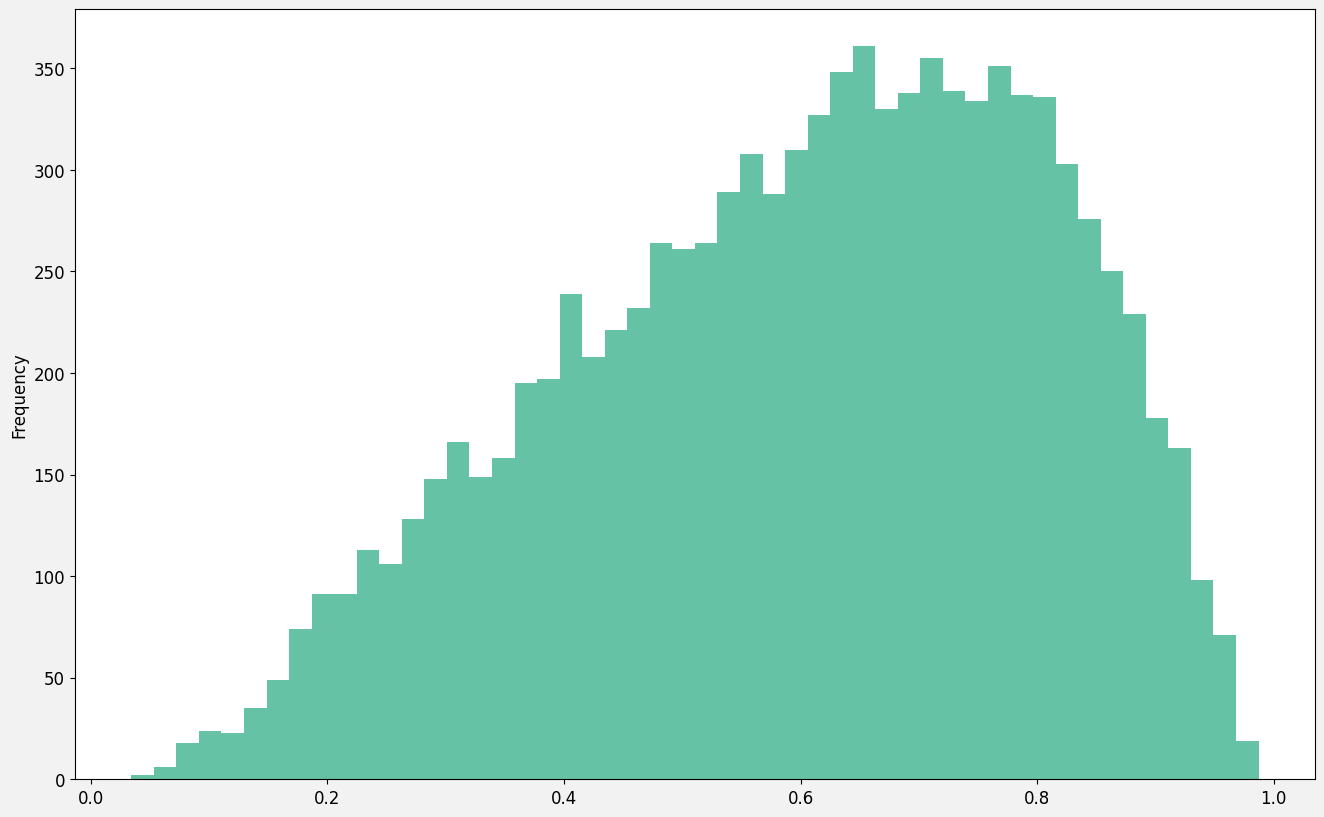

In [10]:
# Creating correlation between income and probabilities of voting:
xs = .5 + .01 * income

# Inverse logit converts to 0 - 1 scale:
ps = pd.Series([np.exp(x) / (1 + np.exp(x)) for x in xs])

ps.plot.hist(bins = 50)
plt.show()

In [14]:
# Generate 0/1 data based on probabilities above using a bernoulli distribution:
vote = np.array([spt.bernoulli.rvs(p, size = 1) for p in ps]).flatten()
vote

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

In [17]:
f_df = pd.DataFrame({'income': income, 'vote': vote})
f_df

,income,vote
0,-8.138408,1
1,41.496171,1
2,33.892765,1
3,-123.385091,1
4,-7.373921,0
...,...,...
9995,-66.003390,1
9996,-110.264491,1
9997,-37.080501,0
9998,-62.140800,0


In [18]:
# Run linear probability regression of vote on income:
fmod1 = smf.ols('vote ~ income', data = f_df).fit()
fmod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   vote   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     2067.
Date:                Tue, 05 Dec 2023   Prob (F-statistic):               0.00
Time:                        17:48:37   Log-Likelihood:                -6120.0
No. Observations:               10000   AIC:                         1.224e+04
Df Residuals:                    9998   BIC:                         1.226e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5977      0.004    133.921      0.000       0.589       0.606
income         0.0020   4.47e-05     45.463      0.000       0.002       0.002
==============================================================================
Omnibus:                    24139.440   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              829.915
Skew:                          -0.296   Prob(JB):                    6.11e-181
Kurtosis:                       1.719   Cond. No.                         99.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

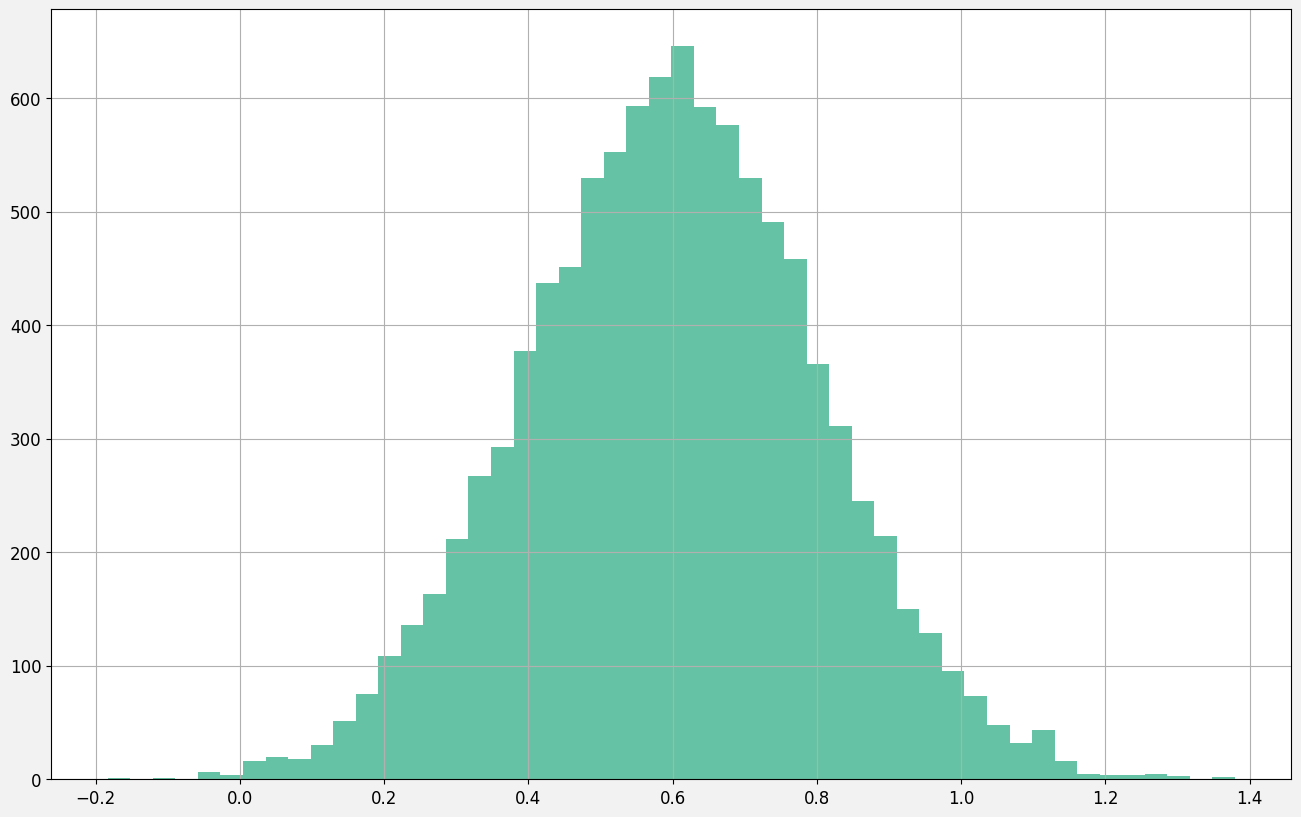

In [21]:
predictions = pd.Series(fmod1.predict())
predictions.hist(bins = 50)
plt.show()

### Logistic regression

In [24]:
# Running a logistic regression:
flog_mod0 = smf.glm('vote ~ income', data = f_df, family = sm.families.Binomial()).fit()
flog_mod0.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                   vote   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9998
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5794.6
Date:                Tue, 05 Dec 2023   Deviance:                       11589.
Time:                        19:28:51   Pearson chi2:                 9.93e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1716
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4814      0.023     21.120      0.000       0.437       0.526
income         0.0103      0.000     37.972      0.000       0.010       0.011
==============================================================================
"""

We are not using ols, but instead generalized linear models (glm), estimated by maximum likelihood. Generalized mean that we are not constrained to the assumption of normal distribution. Here I indicate that we have a binomial distribution. <br><br> GLM are also characterized by a link function, this is a tranformation of the y-variable. In this case, the link function is the logit function $(\frac{e^x}{1 - e^x})$, since I am estimating a model that looks like: $logit(vote_i) = a + b \cdot income_i$, or: $vote_i = invlogit(a + b \cdot income_i)$. <br><br> We are able to estimate the parameters, but because of the non-linear transformation, we cannot interpret the coefficients as probabilities as in the linear probability model. <br><br> There is no $\sigma$ term in the output, in the logistic regression there is no seperate error term, the uncertainty in the model comes from the mapping of the 0/1 data to probabilities (the binomial distribution).

### Real data with logistic.

In [25]:
# Fitting the logistic regression model with the actual data:
mod1 = smf.glm('rvote ~ income', data = politics92, family = sm.families.Binomial()).fit()
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  rvote   No. Observations:                 1356
Model:                            GLM   Df Residuals:                     1354
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -867.26
Date:                Tue, 05 Dec 2023   Deviance:                       1734.5
Time:                        19:41:51   Pearson chi2:                 1.36e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01776
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4528      0.185     -7.832      0.000      -1.816      -1.089
income         0.2668      0.055      4.844      0.000       0.159       0.375
==============================================================================
"""

In [41]:
# Add jitter to the data to make it easier to understand:
N = politics.shape[0]
income_j = politics['income'] + spt.uniform(-0.25, 0.5).rvs(size = N)
rvote_j = politics['rvote'] + spt.uniform(-0.05, 0.1).rvs(size = N)

In [42]:
mod1.params

Intercept   -1.452783
income       0.266840
dtype: float64

In [43]:
def invLogit(x):
    return np.exp(x) / (1 + np.exp(x))

In [44]:
a = mod1.params.iloc[0]
b = mod1.params.iloc[1]

x_line = np.linspace(-2, 8, N)
y_line = invLogit(a + b * x_line)

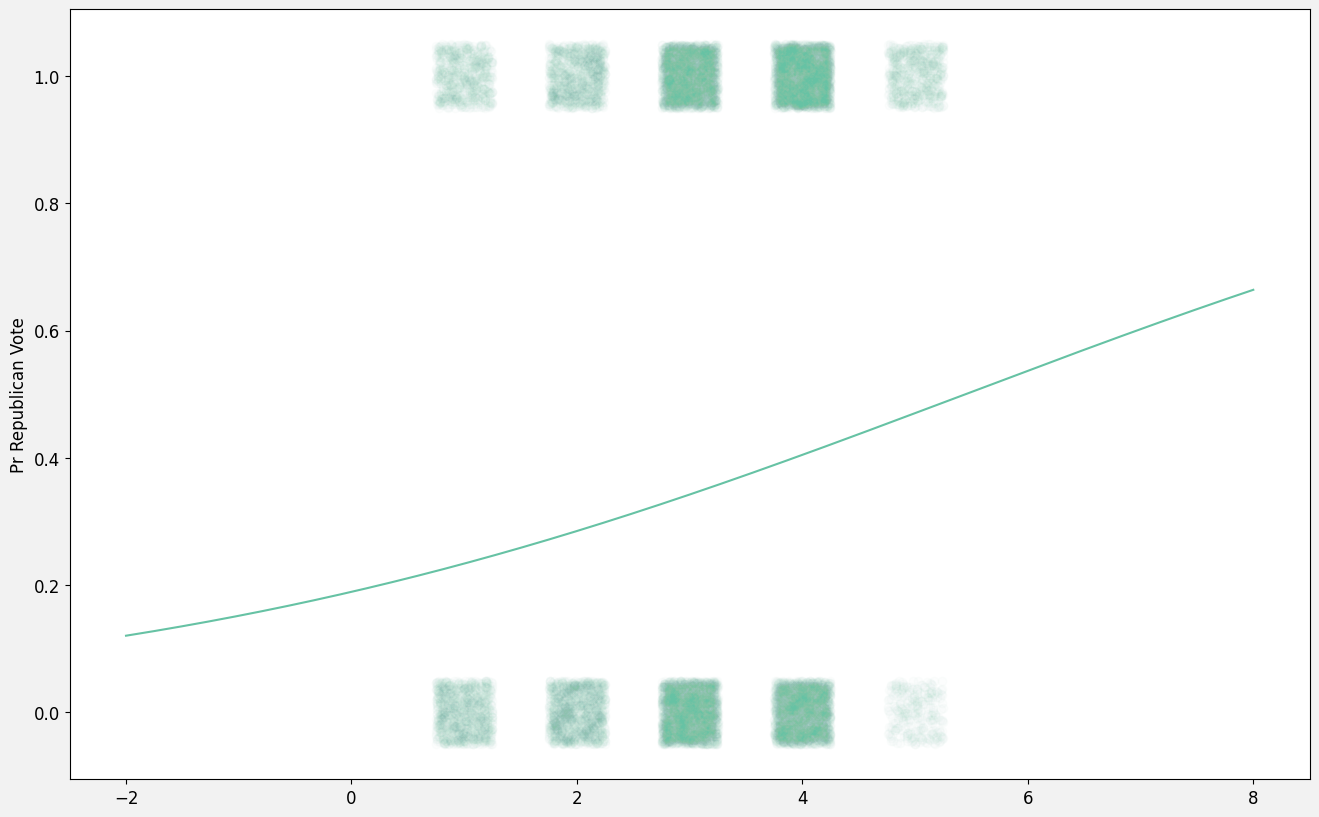

In [45]:
fig, ax = plt.subplots()
ax.scatter(income_j, rvote_j, alpha = .02)
ax.plot(x_line, y_line)
ax.set_ylabel('Pr Republican Vote')
plt.show()

In [46]:
# The probability of someone in the 3 income category for voting republican:
invLogit(mod1.params.iloc[0] + mod1.params.iloc[1] * 3)

0.3424794684426433

In [47]:
# Difference in probability of voting prepublican, for example for categories 3 and 4:
invLogit(mod1.params.iloc[0] + mod1.params.iloc[1] * 4) - invLogit(mod1.params.iloc[0] + mod1.params.iloc[1] * 3)

0.06233975427031979

##### Divide-by-four rule

Dividing the regression coefficient by four can be used as a quick approximation for an upper-bound on the probibalistic interpretation of the coefficient. Like for above, we can take the estimated coefficient on the income variable: .23 / 4 = .058, this can be compared to the estimated coefficient in the linear probability model. 

##### Prediction

In [48]:
# Generate a prediction point estimate from the model with predict:
mod1.predict(exog = dict(income = 4))

0    0.404819
dtype: float64

In [49]:
# To get more information, like standard error and confidence intervals, use get_prediction:
prediction = mod1.get_prediction(exog = dict(income = 4))
print(prediction.predicted_mean[0]) # point estimate
print('Standard error: ', prediction.se_mean[0])
print('95% confidence interval: ', prediction.conf_int()[0])

0.4048192227129631
Standard error:  0.017414035516460397
95% confidence interval:  [0.37119786 0.43935806]


##### Displaying the result of multiple regression.

In [51]:
# Show the results for multiple regressions. Run the regressions using groupby, and iterate over the groups.
presidential = np.arange(1952, 2001, 4)

politics_pres = politics.loc[politics['year'].isin(presidential)].copy()
election_groups = politics_pres.groupby('year')

labels = []
income_b = []
income_SE = []

for year, election in election_groups:
    mod_m = smf.glm('rvote ~ income', data = election, family = sm.families.Binomial()).fit()
    vcov = mod_m.cov_params()

    labels.append(year)
    income_b.append(mod_m.params.iloc[1])
    income_SE.append(np.sqrt(vcov.iloc[1, 1]))

labels = pd.Series(labels)
income_b = pd.Series(income_b)
income_SE = pd.Series(income_SE)

In [52]:
CI_min = income_b - income_SE
CI_max = income_b + income_SE

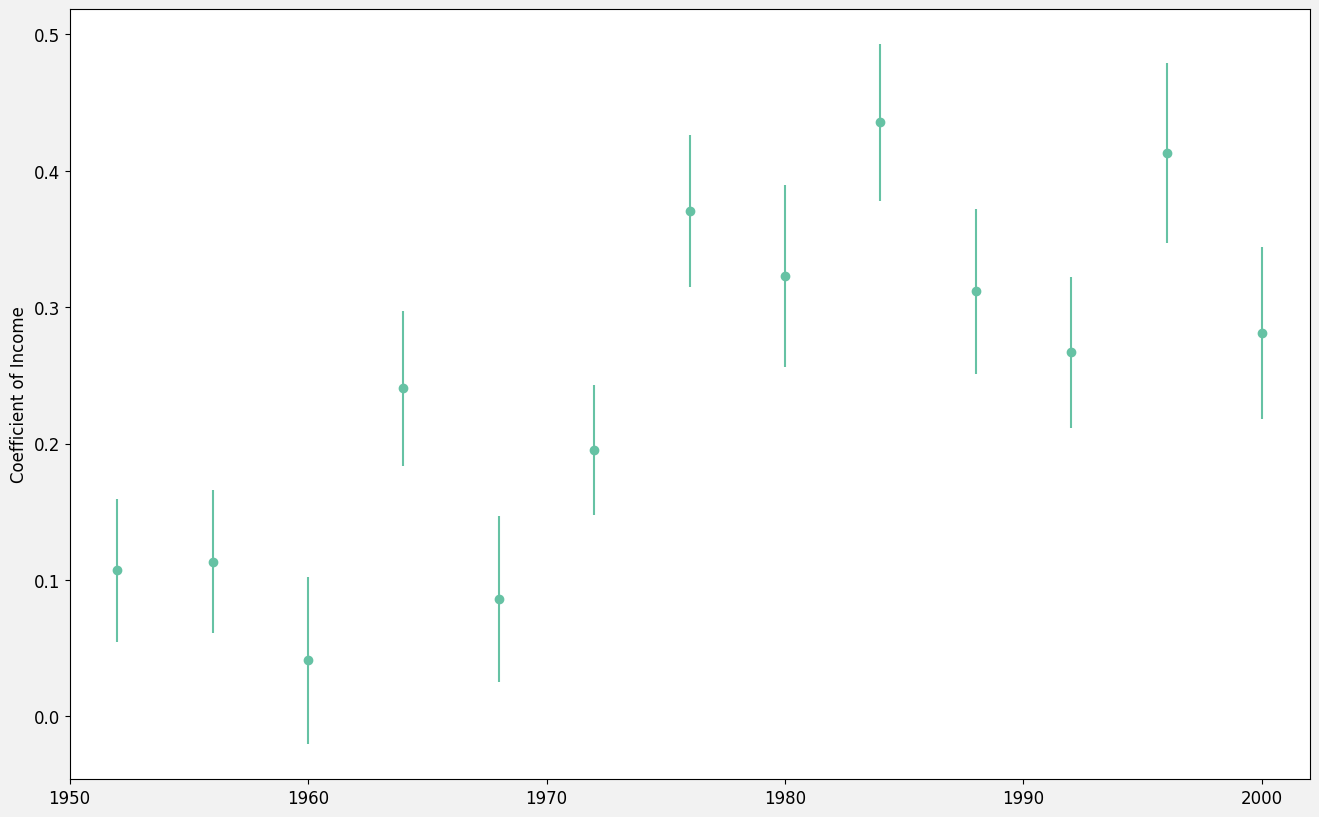

In [53]:
fig, ax = plt.subplots()
ax.scatter(labels, income_b)
ax.vlines(x = labels, ymin = CI_min, ymax = CI_max)
ax.set_xlim(1950, 2002)
ax.set_ylabel('Coefficient of Income')
plt.show()

This shows the cofficient on income. The lines represent +/- 1 standard devations, they can therefor be interpreted as 68% confidence intervals.

##### Oil Drilling

In [54]:
drilling = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/drilling.csv")

In [55]:
drilling = drilling.loc[drilling['year'] != 2020].copy()

In [56]:
drilling.head()

,year,NpdidLicence,orgnr,nDrills,nDry,LongName,ValidFrom,ValidTo,revenues,oper_revenues,fin_instruments,oper_profit,ebitda,profit,inventory_use,wage_costs,only_wage,depreciation,other_oper_costs,total_oper_costs,inventory,total_assets,total_equity,dividend,total_debt,accounts_rec,other_fin_instruments,fixed_assets,cash,change_inventory,short_term_debt,current_assets,pension_costs,rent_costs,profitability,liquidity,solidity,NOK_USD,brent,brent_l1,brent_l2,d_brent,d_brent_l1,d_brent_l2,d_brent_pos,d_brent_neg,d_brent_pos_l1,d_brent_pos_l2,d_brent_neg_l1,d_brent_neg_l2,licenceStart,licenceYears,licenceOwnerYears,d2005,nComp
0,1966,20756,914048990,1,0.0,Esso Exploration and Production Norway A/S,1965-09-01,2004-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1965-09-01,1,1,0,5
1,1966,20780,914048990,1,1.0,Esso Exploration and Production Norway A/S,1965-09-01,1977-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1965-09-01,1,1,0,5
2,1967,20756,914048990,3,3.0,Esso Exploration and Production Norway A/S,1965-09-01,2004-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1965-09-01,2,2,0,5
3,1967,20804,927533081,1,1.0,Amoco Norway Oil Company,1965-09-01,1989-04-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1965-09-01,2,2,0,5
4,1967,20884,948138646,1,1.0,Phillips Petroleum Company Norway,1965-09-01,1968-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1965-09-01,2,2,0,5


In [57]:
# Create a new column for whether a company has or has not drilled in a given year:
drilling['drilled'] = np.where(drilling['nDrills'] > 0, 1, 0)

##### Descriptives

C:\Users\sebal\AppData\Local\Temp\ipykernel_17512\1992821464.py:2: FutureWarning: The provided callable <function mean at 0x000001F074532E60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  prByYear = drilling.groupby('year')['drilled'].aggregate(np.mean)


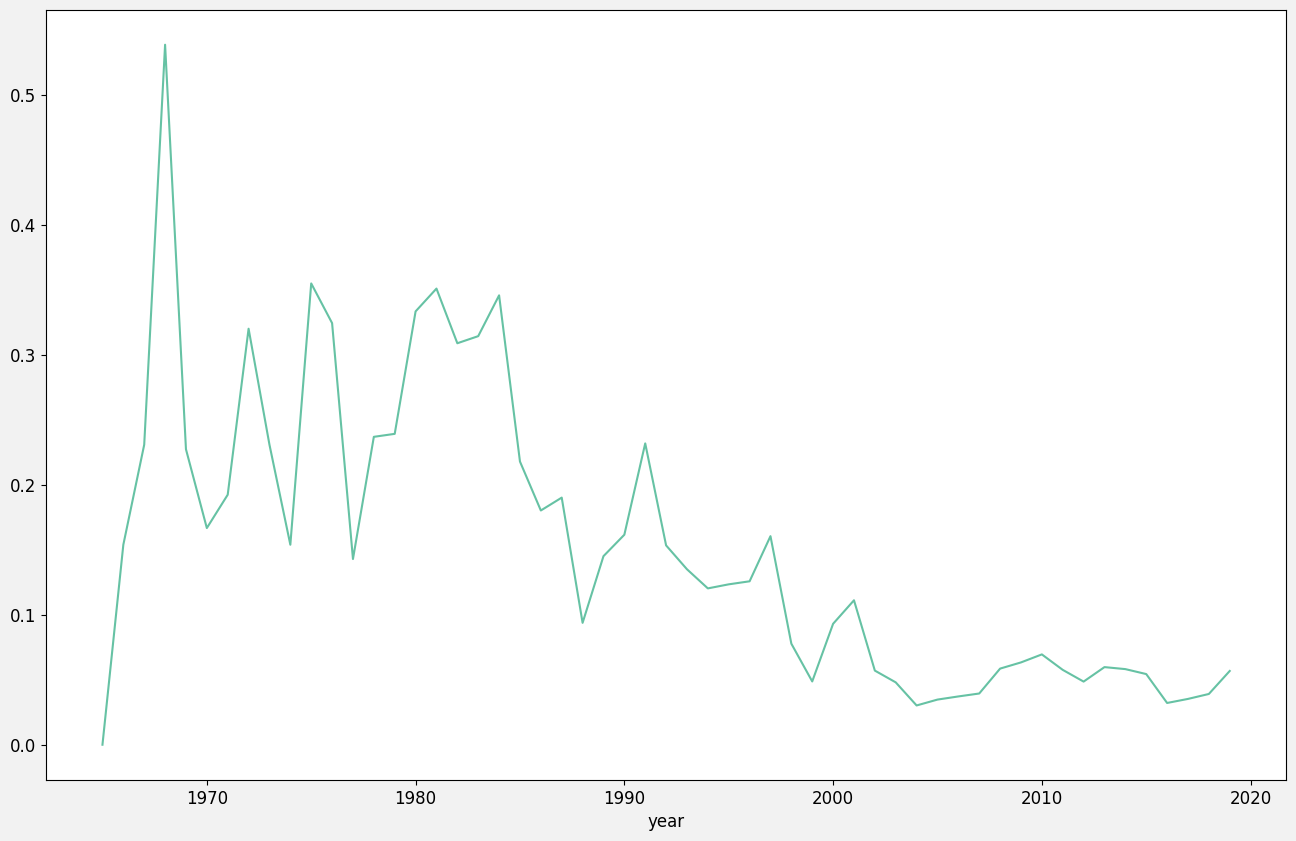

In [59]:
# How has the probability of drilling changed over time. I aggregate by year and get the mean probability of drilling every year:
prByYear = drilling.groupby('year')['drilled'].aggregate(np.mean)
prByYear.plot()
plt.show()

The probability has a lot of variation, but it seems to be declining over time.

In [60]:
drill_mod1 = smf.glm('drilled ~ year', data = drilling, family = sm.families.Binomial()).fit()
drill_mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                drilled   No. Observations:                12528
Model:                            GLM   Df Residuals:                    12526
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3293.5
Date:                Tue, 05 Dec 2023   Deviance:                       6586.9
Time:                        21:14:20   Pearson chi2:                 1.26e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.03343
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    103.3713      4.978     20.764      0.000      93.614     113.129
year          -0.0528      0.002    -21.220      0.000      -0.058      -0.048
==============================================================================
"""

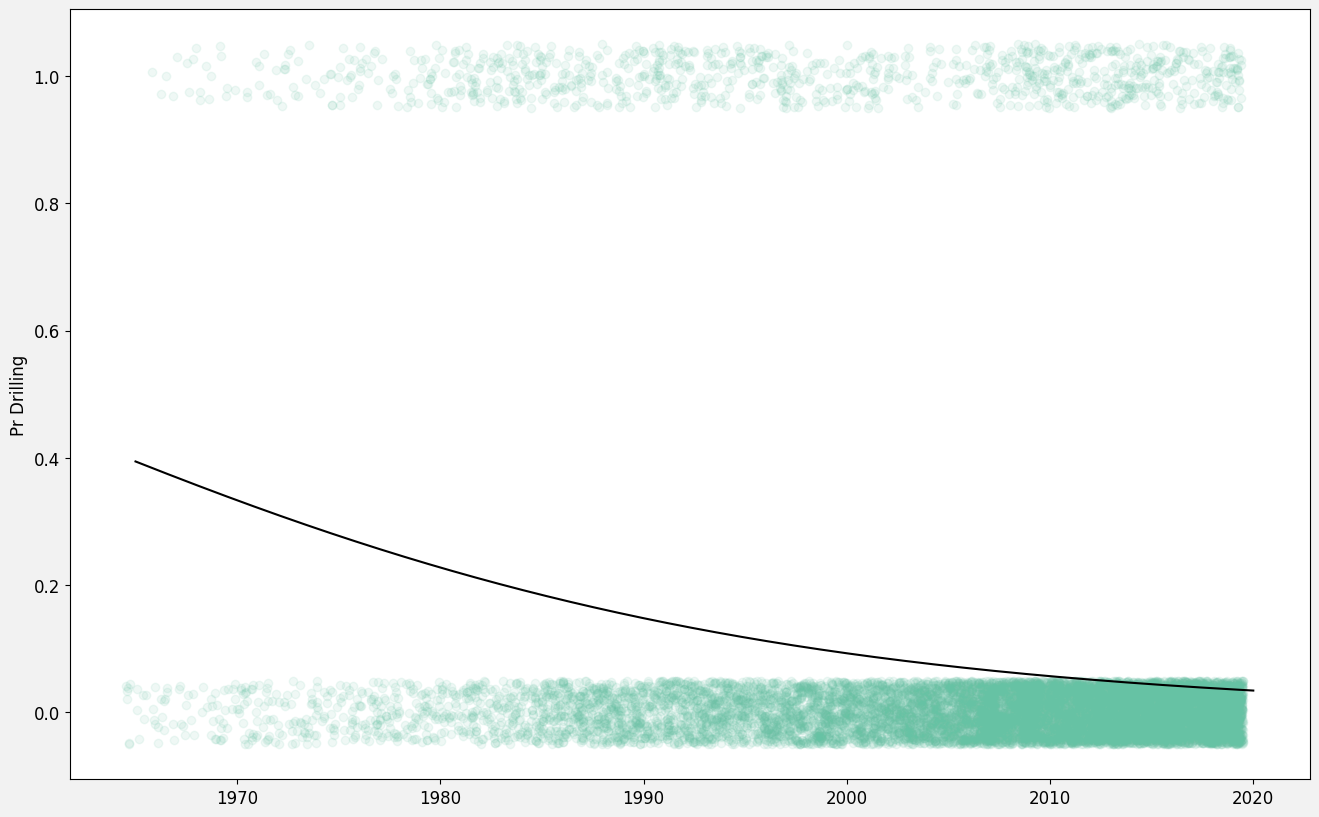

In [61]:
# Divide by four estimates that on average the probability of drilling has declined: 5.2 / 4 = 1.3% per year.
# Plotting:
N = drilling.shape[0]
a = drill_mod1.params.iloc[0]
b = drill_mod1.params.iloc[1]

x_line = np.linspace(1965, 2020, N)
y_line = invLogit(a + b * x_line)

year_j = drilling['year'] + spt.uniform(-.5, 1).rvs(size = N)
drilled_j = drilling['drilled'] + spt.uniform(-.05, .1).rvs(size = N)

fig, ax = plt.subplots()
ax.scatter(year_j, drilled_j, alpha = .1)
ax.plot(x_line, y_line, color = 'black')
ax.set_ylabel('Pr Drilling')
plt.show()

Declining time trend, the probability of drilling towards the end of the period gets quite close to 0. This can be a good reason to prefer the logistic regression in this case, rather than linear probability models.

In [62]:
# Does the oil price affect the probability of drilling? Limiting the data to where we have information on the oil prices. 
drillingOil = drilling.loc[drilling['brent_l1'].notna()].copy()

In [64]:
drill_mod2 = smf.glm('drilled ~ brent + brent_l1', data = drillingOil, family = sm.families.Binomial()).fit()
drill_mod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                drilled   No. Observations:                11476
Model:                            GLM   Df Residuals:                    11473
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2724.4
Date:                Tue, 05 Dec 2023   Deviance:                       5448.9
Time:                        21:24:12   Pearson chi2:                 1.16e+04
No. Iterations:                     6   Pseudo R-squ. (CS):           0.004831
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.1317      0.079    -26.967      0.000      -2.287      -1.977
brent         -0.0086      0.002     -3.608      0.000      -0.013      -0.004
brent_l1      -0.0008      0.002     -0.355      0.723      -0.005       0.004
==============================================================================
"""

In [65]:
# Centering the variables:
drillingOil['year_c'] = drillingOil['year'] - drillingOil['year'].unique().mean()
drillingOil['brent_s'] = (drillingOil['brent'] - drillingOil['brent'].unique().mean()) / drillingOil['brent'].unique().std()
drillingOil['brent_l1_s'] = (drillingOil['brent_l1'] - drillingOil['brent_l1'].unique().mean()) / drillingOil['brent_l1'].unique().std()
print('Brent, std: ', drillingOil['brent_l1'].unique().std())

Brent, std:  32.07939939017523


In [66]:
drill_mod3 = smf.glm('drilled ~ year_c + brent_s + brent_l1_s', data = drillingOil, family = sm.families.Binomial()).fit()
drill_mod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                drilled   No. Observations:                11476
Model:                            GLM   Df Residuals:                    11472
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2683.4
Date:                Tue, 05 Dec 2023   Deviance:                       5366.8
Time:                        21:30:14   Pearson chi2:                 1.16e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01192
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.5137      0.039    -63.746      0.000      -2.591      -2.436
year_c        -0.0587      0.007     -8.705      0.000      -0.072      -0.045
brent_s       -0.1206      0.078     -1.553      0.120      -0.273       0.032
brent_l1_s     0.2204      0.078      2.815      0.005       0.067       0.374
==============================================================================
"""

##### Plotting results and uncertainty.

In [68]:
mean_brent = drillingOil['brent_s'].unique().mean()
mean_brent_l1 = drillingOil['brent_l1_s'].unique().mean()

print(mean_brent, mean_brent_l1)

1.3530843112619095e-16 1.3183898417423734e-16


In [69]:
drillingOil['year'] - drillingOil['year'].unique().mean()

265     -15.5
266     -15.5
267     -15.5
268     -15.5
269     -15.5
         ... 
12547    11.5
12548    12.5
12549    12.5
12550    13.5
12551    15.5
Name: year, Length: 11476, dtype: float64

In [70]:
year_labels = np.arange(1988, 2020, 1)
year_labels

array([1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])

In [71]:
N = drillingOil.shape[0]
a = drill_mod3.params.iloc[0]
b_year = drill_mod3.params.iloc[1]
b_brent = drill_mod3.params.iloc[2]
b_brentl1 = drill_mod3.params.iloc[3]

year_new = np.linspace(-15.5, 15.5, N)
y_line = invLogit(a + b_year * year_new)

year_j = drillingOil['year_c'] + spt.uniform(-.5, 1).rvs(size = N)
drilled_j = drillingOil['drilled'] + spt.uniform(-.05, .1).rvs(size = N)

y_line

array([0.16748796, 0.16746584, 0.16744373, ..., 0.03156702, 0.03156217,
       0.03155733])

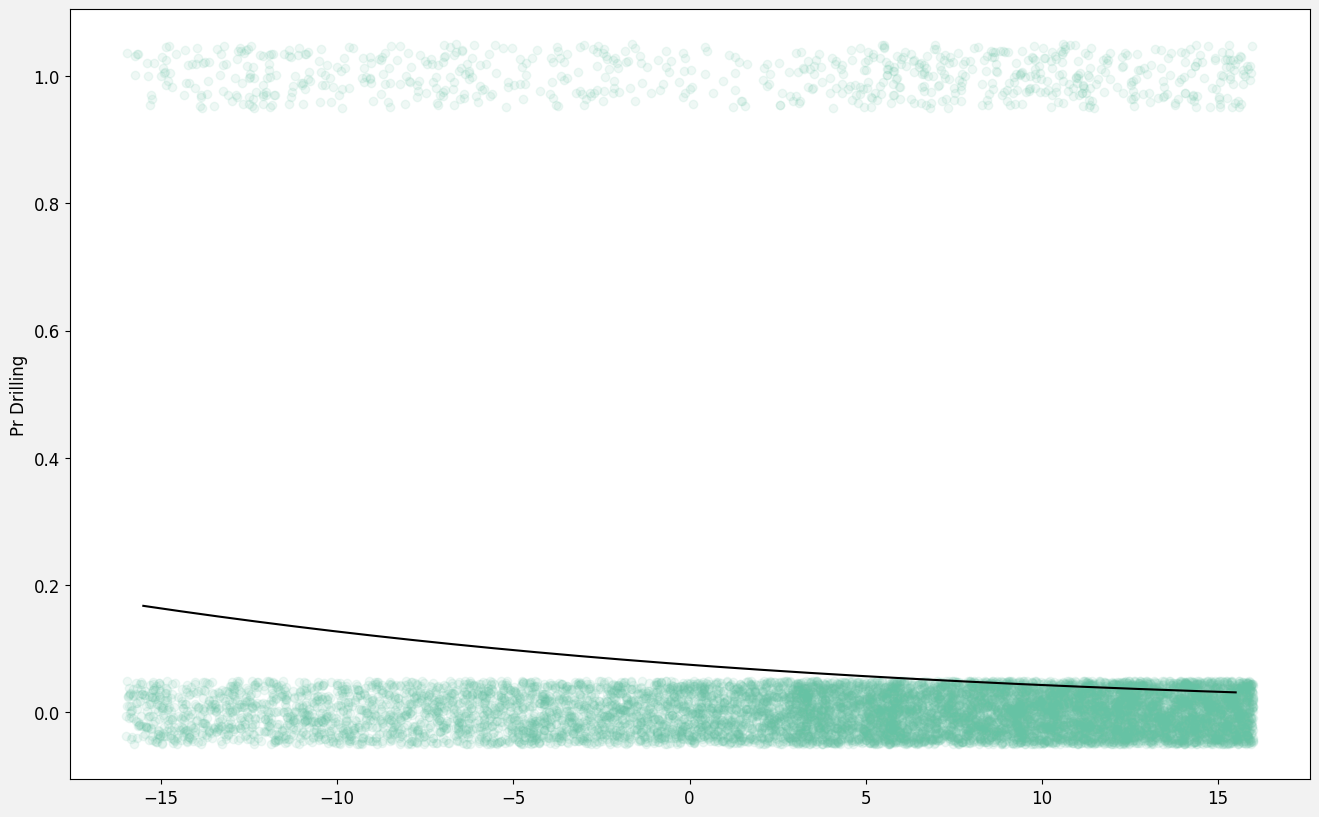

In [72]:
fig, ax = plt.subplots()
ax.scatter(year_j, drilled_j, alpha = .1)
ax.plot(year_new, y_line, color = 'black')
ax.set_ylabel('Pr Drilling')
plt.show()

In [73]:
# Now looking at the effect of a high-price scenario, with oil prices a standard deviation higher (32 usd)
y_line_high = invLogit(a + b_year * year_new + b_brent + b_brentl1)

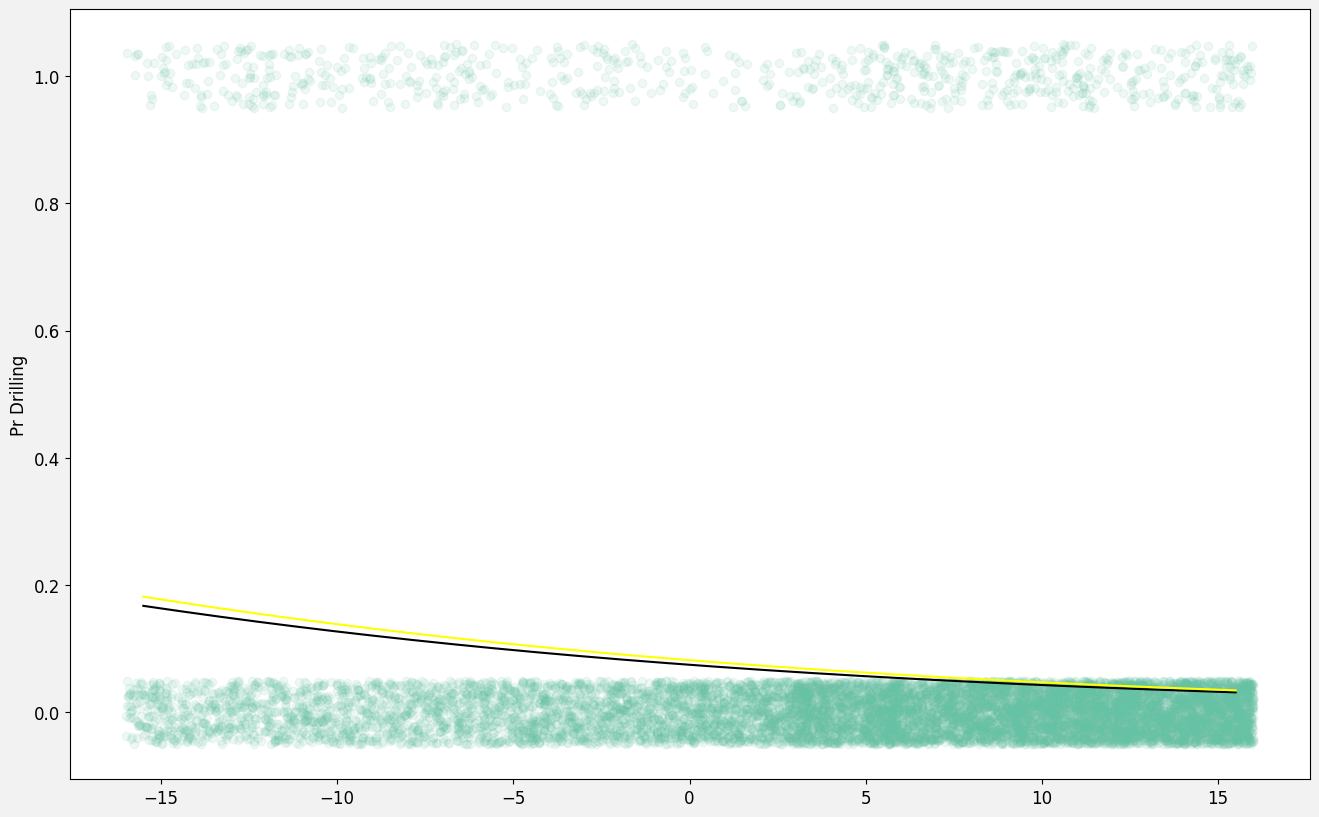

In [74]:
fig, ax = plt.subplots()
ax.scatter(year_j, drilled_j, alpha = .1)
ax.plot(year_new, y_line, color = 'black')
ax.plot(year_new, y_line_high, color = 'yellow')
ax.set_ylabel('Pr Drilling')
plt.show()

##### Simulating and displaying uncertainty in a logistic regression

In [75]:
# Generating inferential and predictive uncertainty through simulation. 
def logSim(regMod):
    nmk = regMod.df_resid
    bs_vcov = regMod.cov_params()
    V_sim = np.array(bs_vcov) * np.sqrt(nmk / np.random.chisquare(nmk, 1))
    bs = regMod.params

    bs_sim = np.random.multivariate_normal(bs, V_sim, 1)

    return bs_sim.flatten()

In [76]:
nsim = 50
bs_sims = []

for i in range(nsim):
    param_sim = logSim(drill_mod3)
    bs_sims.append(param_sim)

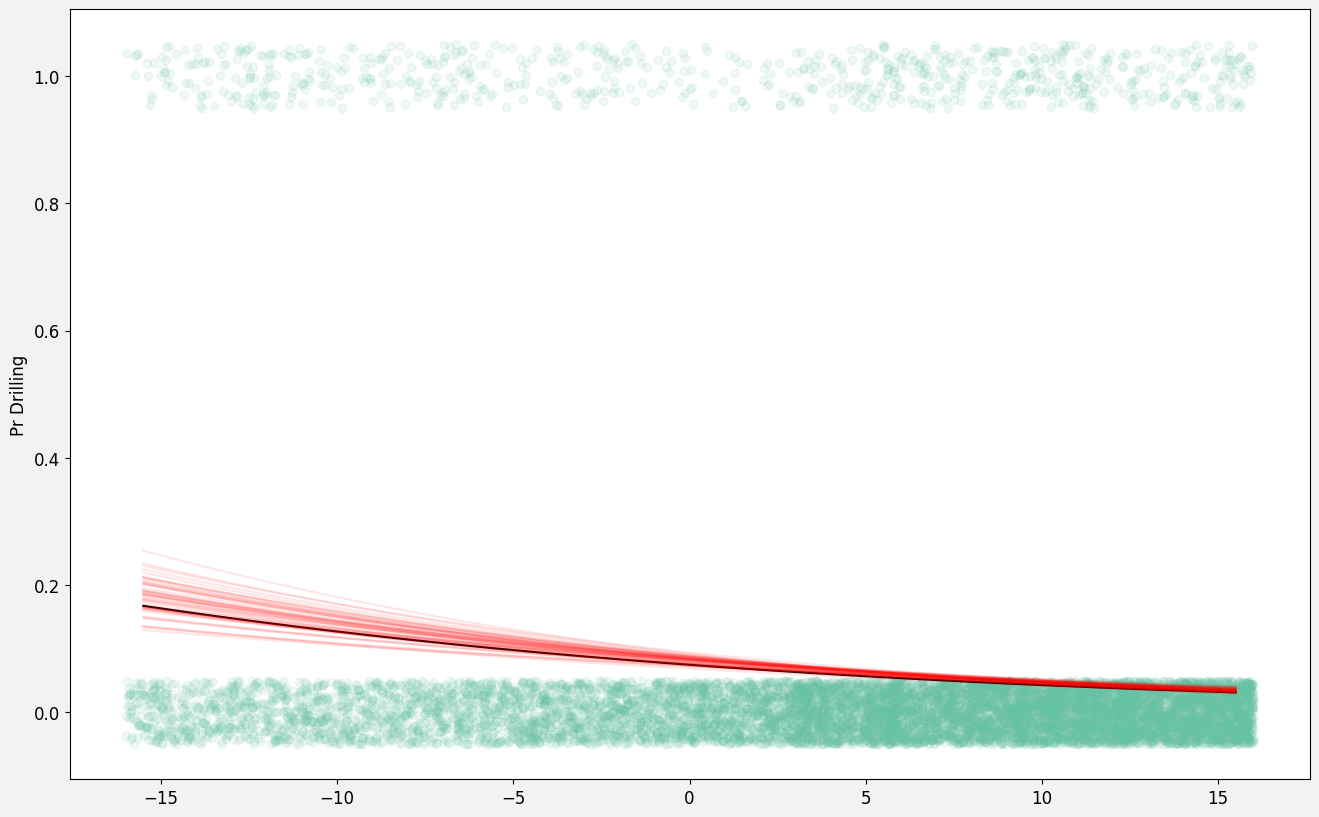

In [77]:
fig, ax = plt.subplots()
ax.scatter(year_j, drilled_j, alpha = .1)
ax.plot(year_new, y_line, color = 'black')
ax.set_ylabel('Pr Drilling')

for i in range(nsim):
    y_line_sim = invLogit(bs_sims[i][0] + bs_sims[i][1] * year_new + bs_sims[i][2] + bs_sims[i][3])
    ax.plot(year_new, y_line_sim, color = 'red', alpha = .1)

plt.show()

In [79]:
# Generate the predictive distribution for the probability of drilling in the year corresponding to 15.5 (2019) and an oil price that is two standard deviations over the mean value (about 100 usd a barrel).
n = 100
year_new = 15.5
oil_new = 2
oil_l_new = 2
nsim = 4000
bs_sims = []
drilling_sim = []

for s in range(nsim):
    param_sim = logSim(drill_mod3)
    bs_sims.append(param_sim)
    p_new = invLogit(param_sim[0] + param_sim[1] * year_new + param_sim[2] * oil_new + param_sim[3] * oil_l_new)
    drilling_sim.append(spt.binom.rvs(100, p_new)) # A binomial with n = 100 draws, and probability of success p_new.

drilling_sim = pd.Series(drilling_sim)

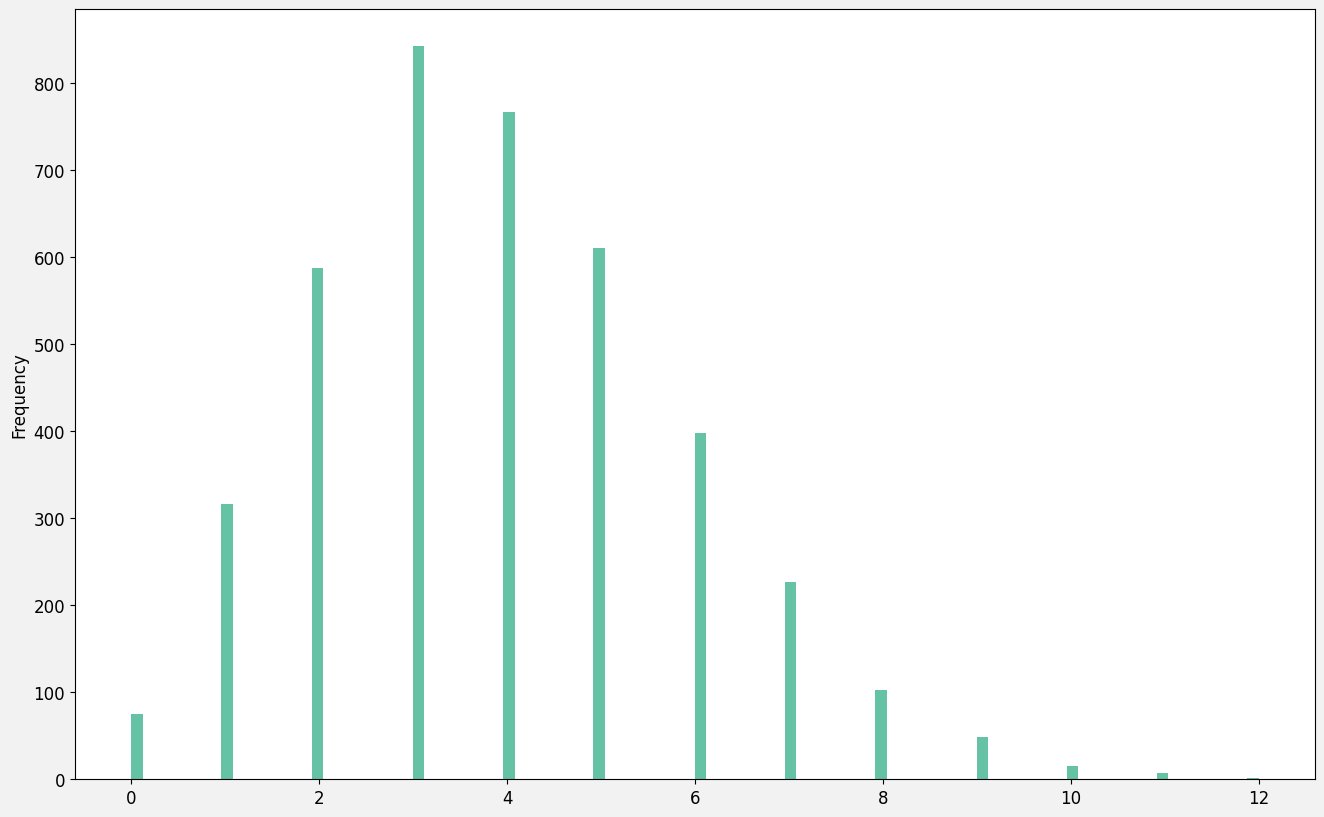

In [80]:
drilling_sim.plot.hist(bins = 100)
plt.show()

In [81]:
# By dividing by n = 100, we get the mean predicted preobability of drilling:
np.mean(drilling_sim) / n

0.0390625

In [82]:
# Can also estimate the standard error:
np.std(drilling_sim) / n

0.019538323719039973